In [1]:
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data = open('sarcasm.txt', 'r').read().splitlines()

In [3]:
data = data[:30000] # smaller dataset for my CPU not to overload

In [4]:
vocabs = ['~'] + list(sorted(set(''.join(data)))) # '~' is the special token that we'll use to help the network learn the end of the sentence
print(len(vocabs))

82


In [5]:
stoi = {s:i for i,s in enumerate(vocabs)}
itos = {i:s for i,s in enumerate(vocabs)}

In [6]:
def build_dataset(data):
  
  x, y = [],[]
  for d in data:
    nx, ny = [], []
    for ch in '~' + d + '~':
      nx.append(stoi[ch])
      ny.append(stoi[ch])
    x.append(torch.tensor(nx[:-1]))
    y.append(torch.tensor(ny[1:]))
    
  return x,y

In [7]:
split = int(0.9*len(data))
xtr, ytr = build_dataset(data[:split])
xval, yval = build_dataset(data[split:])

In [8]:
# model hyper parameters
vocab_size = len(vocabs)
n_hidden   = 200
n_embd     = vocab_size # to create square embedding table

In [9]:
class SelectOutput(nn.Module):
  def __call__(self, x):
    self.out = x[0]
    self.h   = x[1]
    return self.out

In [10]:
model = nn.Sequential(
  nn.Embedding(vocab_size, n_embd),
  nn.LSTM(n_embd, n_hidden), SelectOutput(),
  nn.Linear(n_hidden, vocab_size)
)
print(f"number of parameters = {sum([p.nelement() for layer in model for p in layer.parameters()])}")

number of parameters = 250406


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3*2)
lossi     = []
tsatu     = []
max_steps = 500000

for i in range(1,max_steps+1):
  # input 
  ix = torch.randint(0, len(xtr), (1,))
  x,y= xtr[ix], ytr[ix]
  
  # zero grad 
  optimizer.zero_grad()

  # forward pass
  logits = model(x)
  loss   = F.cross_entropy(logits, y)

  # backward pass
  loss.backward()

  # update
  optimizer.step()

  lossi.append(loss.item())
  satu = [i>0.97 for i in model[2].out.abs().view(-1).tolist()]
  persatu = (satu.count(True) / len(satu)) * 100
  tsatu.append(persatu)

  # print once in a while
  if i % int(max_steps/20) == 0:
    print(f"Epoch: {i}   |  loss = {loss.item():.4f}    |   layerSaturation = {persatu:.2f}%")

Epoch: 25000   |  loss = 1.5654    |   layerSaturation = 0.12%
Epoch: 50000   |  loss = 1.5459    |   layerSaturation = 0.10%
Epoch: 75000   |  loss = 1.1463    |   layerSaturation = 0.13%
Epoch: 100000   |  loss = 1.2291    |   layerSaturation = 0.08%


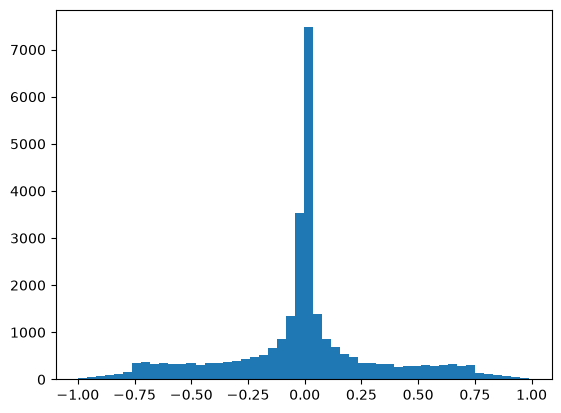

In [19]:
plt.hist(model[2].out.view(-1).tolist(), 50);

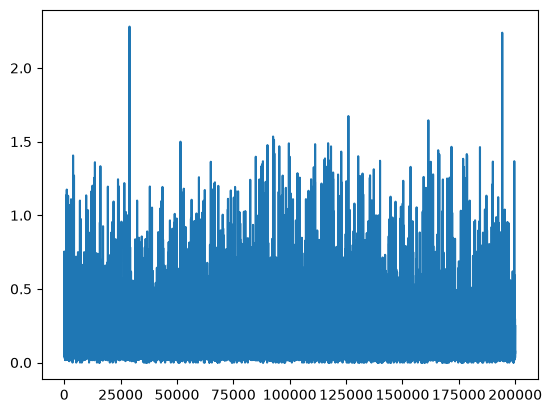

In [20]:
plt.plot(tsatu)

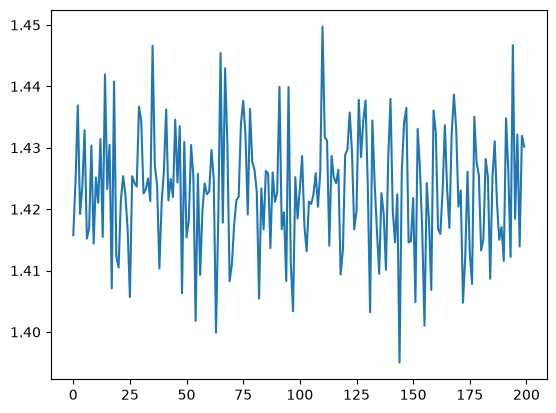

In [21]:
plt.plot(torch.tensor(lossi).view(1000, -1).mean(0))

In [22]:
def test_val(v=''):
  dataset = {
    'train': (xtr, ytr),
    'val': (xval, yval),
  }

  x,y    = dataset[v]
  xlossi = []
  if v=='train':
    for i in range(len(xtr)):
      xloss = F.cross_entropy(model(x[i]), y[i])
      xlossi.append(xloss.item())

  else:
    for i in range(len(xval)):
      xloss = F.cross_entropy(model(x[i]), y[i])
      xlossi.append(xloss.item())

  loss = torch.tensor(xlossi).mean()

  print(f"{v} loss = {loss.item():.6f}")

In [23]:
test_val('train')
test_val('val')

train loss = 1.412604
val loss = 1.446190


In [24]:
def sample(num_samples):
  
  for _ in range(num_samples):
    ix = stoi['~']
    h = None
    out = []

    while True:
      x = torch.tensor([ix])
      emb = model[0](x)
      rnn_out, h = model[1](emb, h)
      x = rnn_out

      for layer in model[3:]:
        x = layer(x)

      probs = F.softmax(x[-1], dim=0)
      ix = torch.multinomial(
        probs,
        num_samples=1
      ).item()

      if ix == 0:
        break
      out.append(itos[ix])

    print(''.join(out))
    print('')

In [25]:
# to search whether the model is getting some words type from the data or it's just making them up
def search(x: str):
  count= 0
  cont = []
  for c in data:
    if x.lower() in c.lower():
      cont.append(c)
      count+=1
  print(f'{count} matches found...')
  return cont if cont else None

In [41]:
sample(5)

I asked Women and good man when it's antout with my emails in pokemer.

She was time reep a nuz hell and making goes when I could die. Your cherterunks.

How do you call a black part on a principline? In 10 Headhines?

Why is other amn fun here? To would hear I was mail-shelent.

What do you catch a sucking believing on a racist? A asido



In [42]:
search('')

0 matches found...


In [43]:
trainloss1 = 1.412604
valloss1   = 1.446190